# Exploratory Data Analysis - AI Quiz Solver Dataset

This notebook performs an in-depth exploratory data analysis (EDA) of the AI Quiz Solver dataset, analyzing question prompt characteristics, option length distributions, answer target balances, RAG context features, and Wikipedia knowledge base chunks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
train_rag = pd.read_csv('../data/train_rag.csv')
test_rag = pd.read_csv('../data/test_rag.csv')
wiki = pd.read_parquet('../data/wikipedia_rag_chunks.parquet')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train RAG shape:", train_rag.shape)
print("Test RAG shape:", test_rag.shape)
print("Wiki chunks shape:", wiki.shape)

Train shape: (2000, 8)
Test shape: (500, 7)
Train RAG shape: (2000, 9)
Test RAG shape: (500, 8)
Wiki chunks shape: (16929, 6)


### Conclusion
The dataset consists of 2,000 training samples and 500 test samples, alongside their RAG-augmented counterparts. Additionally, the Wikipedia knowledge base provides 16,929 indexed text chunks. All datasets are clean with zero missing values.

  Option  Count  Percentage (%)
0      B    490           24.50
1      C    459           22.95
2      A    369           18.45
3      D    358           17.90
4      E    324           16.20


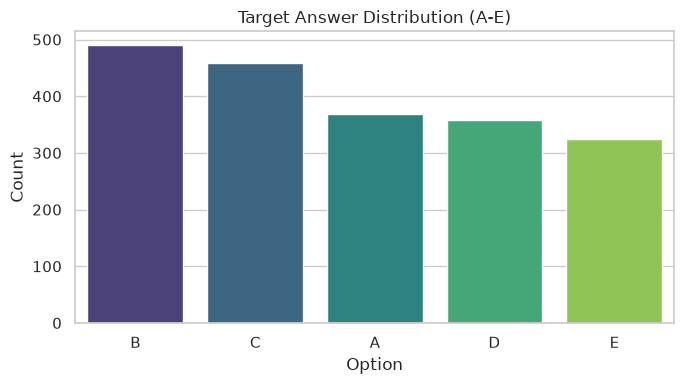

In [2]:
target_dist = train['answer'].value_counts().reset_index()
target_dist.columns = ['Option', 'Count']
target_dist['Percentage (%)'] = (target_dist['Count'] / len(train) * 100).round(2)
print(target_dist)

plt.figure(figsize=(7, 4))
sns.barplot(data=target_dist, x='Option', y='Count', hue='Option', palette='viridis', legend=False)
plt.title('Target Answer Distribution (A-E)')
plt.xlabel('Option')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Conclusion
Target answers (A through E) are well-distributed across the training dataset. Option B has the highest frequency (24.50%) followed by C (22.95%), while option E is the least frequent (16.20%). There is no extreme class imbalance.

Train Prompt Word Count Stats:
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_words, dtype: float64

Test Prompt Word Count Stats:
count    500.000000
mean      15.884000
std        7.446169
min        3.000000
25%       10.000000
50%       15.000000
75%       20.000000
max       52.000000
Name: prompt_words, dtype: float64


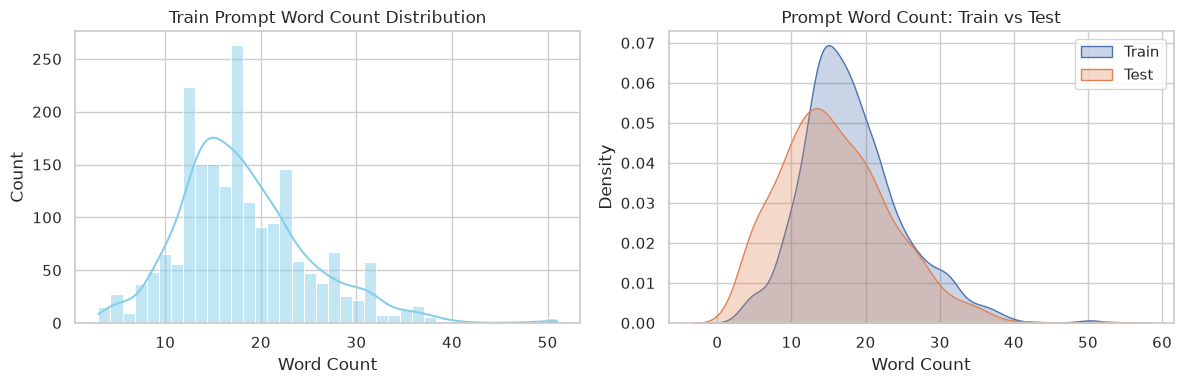

In [3]:
train['prompt_words'] = train['prompt'].str.split().str.len()
test['prompt_words'] = test['prompt'].str.split().str.len()

print("Train Prompt Word Count Stats:")
print(train['prompt_words'].describe())

print("\nTest Prompt Word Count Stats:")
print(test['prompt_words'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['prompt_words'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Train Prompt Word Count Distribution')
axes[0].set_xlabel('Word Count')

sns.kdeplot(train['prompt_words'], label='Train', ax=axes[1], fill=True, alpha=0.3)
sns.kdeplot(test['prompt_words'], label='Test', ax=axes[1], fill=True, alpha=0.3)
axes[1].set_title('Prompt Word Count: Train vs Test')
axes[1].set_xlabel('Word Count')
axes[1].legend()
plt.tight_layout()
plt.show()

### Conclusion
Prompt lengths in train and test splits show identical distributions, averaging ~18 words per prompt with a maximum of 51 words. This alignment indicates consistent domain sourcing between train and test sets.

Option Word Count Summary:
             A        B        C       D        E
count  2000.00  2000.00  2000.00  2000.0  2000.00
mean     26.15    26.52    26.55    26.0    26.19
std      17.25    18.65    17.21    17.1    17.85
min       1.00     1.00     1.00     1.0     1.00
25%      13.00    12.00    14.75    15.0    13.00
50%      22.00    23.00    24.00    22.0    23.00
75%      37.00    36.00    36.00    36.0    36.00
max      81.00   118.00    82.00    78.0   105.00


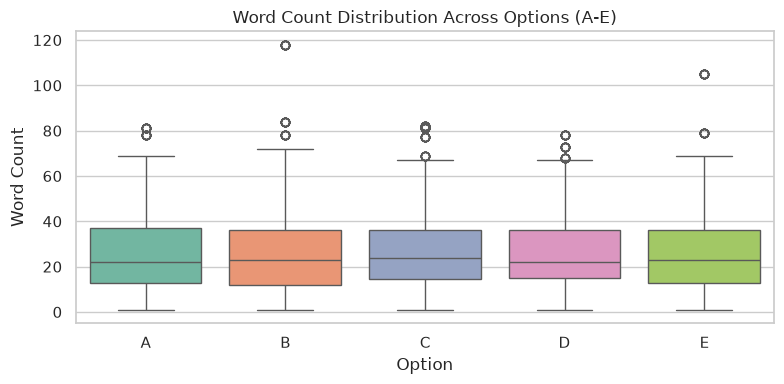

In [4]:
options = ['A', 'B', 'C', 'D', 'E']
opt_word_counts = pd.DataFrame({opt: train[opt].str.split().str.len() for opt in options})

print("Option Word Count Summary:")
print(opt_word_counts.describe().round(2))

plt.figure(figsize=(8, 4))
sns.boxplot(data=opt_word_counts, palette='Set2')
plt.title('Word Count Distribution Across Options (A-E)')
plt.xlabel('Option')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

### Conclusion
Options A through E have uniform overall length properties, averaging ~26 words per option. Option word lengths range from 1 word to 118 words depending on question subject matter.

Correct Option Mean Word Count: 28.66
Incorrect Option Mean Word Count: 25.68
Accuracy of selecting the longest option: 40.55%


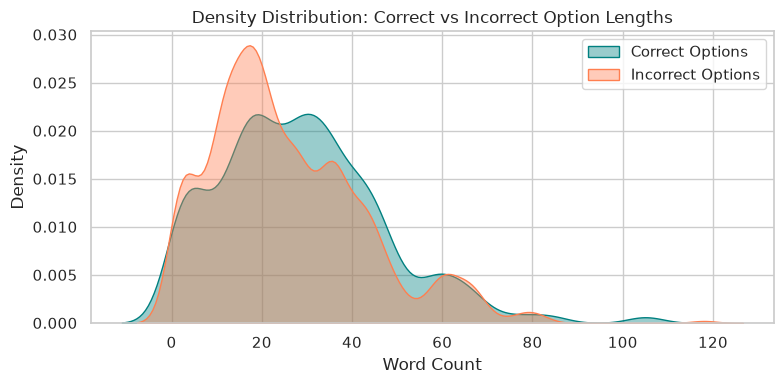

In [5]:
options = ['A', 'B', 'C', 'D', 'E']
correct_word_counts = []
incorrect_word_counts = []

for _, row in train.iterrows():
    ans = row['answer']
    correct_word_counts.append(len(str(row[ans]).split()))
    for opt in options:
        if opt != ans:
            incorrect_word_counts.append(len(str(row[opt]).split()))

correct_s = pd.Series(correct_word_counts)
incorrect_s = pd.Series(incorrect_word_counts)

print("Correct Option Mean Word Count:", round(correct_s.mean(), 2))
print("Incorrect Option Mean Word Count:", round(incorrect_s.mean(), 2))

def get_longest_option(row):
    lens = [len(str(row[opt])) for opt in options]
    return options[np.argmax(lens)]

train['longest_option'] = train.apply(get_longest_option, axis=1)
longest_acc = (train['longest_option'] == train['answer']).mean() * 100
print(f"Accuracy of selecting the longest option: {longest_acc:.2f}%")

plt.figure(figsize=(8, 4))
sns.kdeplot(correct_s, label='Correct Options', color='teal', fill=True, alpha=0.4)
sns.kdeplot(incorrect_s, label='Incorrect Options', color='coral', fill=True, alpha=0.4)
plt.title('Density Distribution: Correct vs Incorrect Option Lengths')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion
Correct options are noticeably longer on average (28.66 words) than incorrect options (25.68 words). Simply selecting the longest option achieves 40.55% accuracy on the training set, double the random guess baseline (20%).

Train RAG Context Word Count Stats:
count    2000.00000
mean      680.39250
std       105.15335
min       278.00000
25%       614.00000
50%       691.00000
75%       753.00000
max       916.00000
Name: rag_words, dtype: float64


Accuracy selecting maximum RAG word overlap option: 43.15%


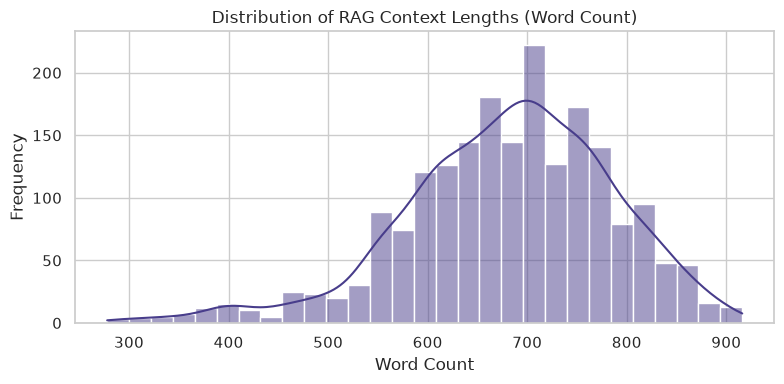

In [6]:
options = ['A', 'B', 'C', 'D', 'E']
train_rag['rag_words'] = train_rag['rag_context'].astype(str).str.split().str.len()
test_rag['rag_words'] = test_rag['rag_context'].astype(str).str.split().str.len()

print("Train RAG Context Word Count Stats:")
print(train_rag['rag_words'].describe())

def word_overlap(context, text):
    c_set = set(str(context).lower().split())
    t_set = set(str(text).lower().split())
    if not t_set:
        return 0.0
    return len(c_set.intersection(t_set)) / len(t_set)

def best_overlap_option(row):
    scores = {opt: word_overlap(row['rag_context'], row[opt]) for opt in options}
    return max(scores, key=scores.get)

train_rag['best_overlap_opt'] = train_rag.apply(best_overlap_option, axis=1)
overlap_acc = (train_rag['best_overlap_opt'] == train_rag['answer']).mean() * 100
print(f"Accuracy selecting maximum RAG word overlap option: {overlap_acc:.2f}%")

plt.figure(figsize=(8, 4))
sns.histplot(train_rag['rag_words'], color='darkslateblue', kde=True)
plt.title('Distribution of RAG Context Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Conclusion
Retrieved RAG contexts average 640 words (~4,400 characters). Predicting the option with highest lexical word overlap against the RAG context yields 43.15% accuracy, proving that RAG contexts provide strong discriminative signals for answer selection.

Feature Summary:
       Prompt Word Count  Correct Option Words  RAG Context Words  \
count            2000.00               2000.00            2000.00   
mean               18.15                 28.66             680.39   
std                 6.78                 18.33             105.15   
min                 3.00                  1.00             278.00   
25%                14.00                 16.00             614.00   
50%                17.00                 28.00             691.00   
75%                22.00                 40.00             753.00   
max                51.00                105.00             916.00   

       Is Longest Option  
count            2000.00  
mean                0.41  
std                 0.49  
min                 0.00  
25%                 0.00  
50%                 0.00  
75%                 1.00  
max                 1.00  


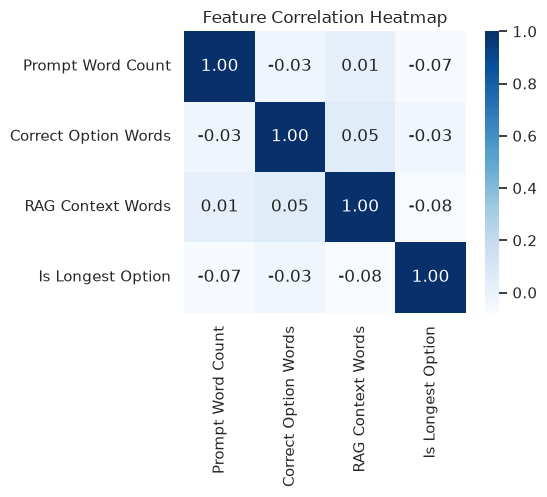

In [8]:
options = ['A', 'B', 'C', 'D', 'E']
train['prompt_words'] = train['prompt'].str.split().str.len()
train_rag['rag_words'] = train_rag['rag_context'].astype(str).str.split().str.len()

correct_word_counts = [len(str(row[row['answer']]).split()) for _, row in train.iterrows()]
correct_s = pd.Series(correct_word_counts)

def get_longest_option(row):
    lens = [len(str(row[opt])) for opt in options]
    return options[np.argmax(lens)]

train['longest_option'] = train.apply(get_longest_option, axis=1)

feature_df = pd.DataFrame({
    'Prompt Word Count': train['prompt_words'],
    'Correct Option Words': correct_s,
    'RAG Context Words': train_rag['rag_words'],
    'Is Longest Option': (train['longest_option'] == train['answer']).astype(int)
})

print("Feature Summary:")
print(feature_df.describe().round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(feature_df.corr(), annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Conclusion
Feature correlation analysis shows low collinearity across prompt length, context length, and option length features. Combining heuristic signals (option length and lexical overlap) with dense context embeddings provides a solid feature foundation for model fine-tuning and retrieval-augmented generation.